In [7]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")

In [16]:
from torch.utils.data import DataLoader

In [8]:
import sys
import os
from pathlib import Path

# Move up one level from 'VisionTranformer' to 'MoT-DAQCNN'
PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f"Project root added: {PROJECT_ROOT}")

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from src.layers.quantum_convolution import QuantumConv2d
from src.utils.data import load_medmnist_dataset

Project root added: /scratch/sp7007/MoT-DAQCNN


In [9]:
import torch
import torch.nn as nn

class QuantumToViT_Deep(nn.Module):
    def __init__(self, num_classes=2, num_layers=8):
        super().__init__()
        self.embedding_dim = 36 # 4 kernels * 9 qubits
        
        # 1. Positional Encoding (Crucial for deep transformers)
        # 81 patches + 1 for GAP or just 81
        self.pos_embedding = nn.Parameter(torch.randn(1, 81, self.embedding_dim))
        
        # 2. The Deeper Encoder (8 Layers)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.embedding_dim, 
            nhead=4, 
            dim_feedforward=128,
            batch_first=True,
            dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 3. Final Head
        self.head = nn.Linear(self.embedding_dim, num_classes)

    def forward(self, x):
        # FIX: Ensure input is on the same device as the model parameters
        x = x.float().to(next(self.parameters()).device)
        
        B, C, H, W = x.shape
        # Reshape: (B, 36, 9, 9) -> (B, 81, 36)
        x = x.view(B, C, H*W).permute(0, 2, 1)
        
        # Add positional info
        x = x + self.pos_embedding
        
        # Pass through 8 layers
        x = self.transformer(x)
        
        # Global Average Pooling
        x = x.mean(dim=1) 
        return self.head(x)

# Initialize
device = "cuda" if torch.cuda.is_available() else "cpu"
vit_model = QuantumToViT_Deep(num_classes=2, num_layers=8).to(device)
print(f"Model initialized with 8 layers on {device}")

Model initialized with 8 layers on cuda


In [10]:
# # --- PLOT 1: ORIGINAL ---
# plt.figure(figsize=(4,4))
# plt.imshow(raw_image.squeeze(), cmap='gray')
# plt.title(f"Original Image\nLabel: {label.item()}")
# plt.axis('off')
# plt.show()

# # --- PLOT 2: ALL 36 QUANTUM FEATURES ---
# fig, axes = plt.subplots(6, 6, figsize=(15, 15))
# fig.suptitle(f"Quantum Feature Map Explosion (36 Channels)\nViT Prediction: {prediction.item()}", fontsize=20)

# # Topology labels for the rows (9 qubits per topology)
# topo_labels = ["Kings", "Horizontal", "Vertical", "Cross"]

# for i in range(36):
#     ax = axes[i // 6, i % 6]
#     img = quantum_features[0, i].cpu().numpy()
    
#     # Identify which topology and which qubit this is
#     topo_idx = i // 9
#     qubit_idx = i % 9
    
#     ax.imshow(img, cmap='magma')
#     if i % 9 == 0:
#         ax.set_ylabel(f"Topo: {TOPOLOGIES[topo_idx]}", fontsize=10, fontweight='bold')
    
#     ax.set_title(f"Qubit {qubit_idx}", fontsize=8)
#     ax.set_xticks([]); ax.set_yticks([])

# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.show()

# print(f"ViT Output Logits: {logits.cpu().numpy()}")

In [11]:
# import json
# import os
# import numpy as np
# import torch
# from tqdm import tqdm
# from torch.utils.data import DataLoader
# from datetime import datetime

# # 1. OVERRIDE THE PARAMETERS HERE
# DATASET_NAME = "breast_mnist"
# KERNEL_SIZE = 3
# STRIDE = 3
# # We use only 4 topologies to keep the embedding dim at 36 for our ViT
# KERNEL_TOPOLOGY_NAMES = ["kings", "horizontal", "vertical", "cross"]
# EVOLUTION_TIME = 2.0
# SCALING_FACTOR = 1.0
# BATCH_SIZE = 16 

# # 2. Setup Paths
# data_root = PROJECT_ROOT / "data"
# output_dir = PROJECT_ROOT / "data" / "quantum_datasets"
# output_dir.mkdir(parents=True, exist_ok=True)

# # 3. Initialize the Quantum Layer
# print("Initializing Quantum Layer for BreastMNIST...")
# q_conv = QuantumConv2d(
#     in_channels=1,
#     kernel_size=KERNEL_SIZE,
#     stride=STRIDE,
#     kernel_topology_names=KERNEL_TOPOLOGY_NAMES,
#     scaling_factor=SCALING_FACTOR,
#     evolution_time=EVOLUTION_TIME,
#     quantum_device="default.qubit",
#     interface="torch",
# ).to(device)

# # 4. Processing Loop (Manual version of the script's main)
# results = {}
# for split in ["train", "val", "test"]:
#     print(f"\n--- Processing {split} split ---")
#     ds = load_medmnist_dataset(DATASET_NAME, split, data_root)
#     loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
    
#     all_features = []
#     all_labels = []
    
#     for images, labels in tqdm(loader, desc=f"  {split}"):
#         images = images.to(device)
#         with torch.no_grad():
#             # Process and cast to float16 or float32 to save space/matching ViT
#             q_out = q_conv(images).cpu().numpy().astype(np.float32)
        
#         all_features.append(q_out)
#         all_labels.append(labels.numpy().squeeze())

#     results[f"{split}_features"] = np.concatenate(all_features, axis=0)
#     results[f"{split}_labels"] = np.concatenate(all_labels, axis=0)

# # 5. Save the Output
# output_filename = f"breast_mnist_vit_k3_s3_custom.npz"
# output_path = output_dir / output_filename

# np.savez_compressed(
#     output_path,
#     train_features=results["train_features"],
#     train_labels=results["train_labels"],
#     val_features=results["val_features"],
#     val_labels=results["val_labels"],
#     test_features=results["test_features"],
#     test_labels=results["test_labels"]
# )

# print(f"\nSUCCESS! Quantum dataset saved to: {output_path}")
# print(f"Total images processed: {len(results['train_labels']) + len(results['val_labels']) + len(results['test_labels'])}")

In [12]:
class QuantumFeatureDataset(torch.utils.data.Dataset):
    def __init__(self, npz_path, split='train'):
        data = np.load(npz_path, allow_pickle=True)
        # Features are (N, 36, 9, 9), Labels are (N,)
        self.features = torch.from_numpy(data[f'{split}_features']).float()
        self.labels = torch.from_numpy(data[f'{split}_labels']).long()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Path to your newly created file
CACHE_PATH = PROJECT_ROOT / "data" / "quantum_datasets" / "breast_mnist_vit_k3_s3_custom.npz"

train_ds = QuantumFeatureDataset(CACHE_PATH, split='train')
val_ds = QuantumFeatureDataset(CACHE_PATH, split='val')

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=32, shuffle=False)

In [13]:
import torch.optim as optim

# 1. Setup
optimizer = optim.AdamW(vit_model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
TOTAL_EPOCHS = 500 # Scratch models need time to learn the basics

history = {'train_acc': [], 'val_acc': []}

for epoch in range(TOTAL_EPOCHS):
    vit_model.train()
    correct, total = 0, 0
    
    for feats, lbls in train_loader:
        # FIX: Explicitly move data to device
        feats, lbls = feats.to(device), lbls.to(device)
        
        optimizer.zero_grad()
        outputs = vit_model(feats)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        
        correct += (outputs.argmax(1) == lbls).sum().item()
        total += lbls.size(0)
    
    # Validation
    vit_model.eval()
    v_correct = 0
    with torch.no_grad():
        for feats, lbls in val_loader:
            feats, lbls = feats.to(device), lbls.to(device)
            v_outputs = vit_model(feats)
            v_correct += (v_outputs.argmax(1) == lbls).sum().item()
            
    t_acc = 100 * correct / total
    v_acc = 100 * v_correct / len(val_ds)
    
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Train Acc: {t_acc:.2f}% | Val Acc: {v_acc:.2f}%")

Epoch 010 | Train Acc: 73.08% | Val Acc: 73.08%
Epoch 020 | Train Acc: 71.06% | Val Acc: 73.08%
Epoch 030 | Train Acc: 71.79% | Val Acc: 76.92%
Epoch 040 | Train Acc: 78.02% | Val Acc: 76.92%
Epoch 050 | Train Acc: 80.04% | Val Acc: 79.49%
Epoch 060 | Train Acc: 80.59% | Val Acc: 76.92%
Epoch 070 | Train Acc: 86.45% | Val Acc: 79.49%
Epoch 080 | Train Acc: 85.90% | Val Acc: 75.64%
Epoch 090 | Train Acc: 87.91% | Val Acc: 78.21%
Epoch 100 | Train Acc: 86.26% | Val Acc: 79.49%
Epoch 110 | Train Acc: 91.03% | Val Acc: 76.92%
Epoch 120 | Train Acc: 88.28% | Val Acc: 80.77%
Epoch 130 | Train Acc: 88.64% | Val Acc: 76.92%
Epoch 140 | Train Acc: 92.49% | Val Acc: 76.92%
Epoch 150 | Train Acc: 89.56% | Val Acc: 79.49%
Epoch 160 | Train Acc: 83.70% | Val Acc: 82.05%
Epoch 170 | Train Acc: 87.18% | Val Acc: 79.49%
Epoch 180 | Train Acc: 91.58% | Val Acc: 75.64%
Epoch 190 | Train Acc: 80.95% | Val Acc: 73.08%
Epoch 200 | Train Acc: 79.30% | Val Acc: 78.21%
Epoch 210 | Train Acc: 73.08% | Val Acc:

In [17]:
test_ds = QuantumFeatureDataset(CACHE_PATH, split='test')

test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

In [18]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Set model to evaluation mode
vit_model.eval()

y_true = []
y_probs = []
y_preds = []

print("Running Evaluation on Test Set...")
with torch.no_grad():
    for feats, lbls in test_loader:
        # Ensure data is moved to the same device as the model
        feats = feats.to(device)
        
        # Forward pass
        logits = vit_model(feats)
        
        # Get probabilities for the positive class (Malignant at index 1)
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = torch.argmax(logits, dim=1)
        
        y_true.extend(lbls.numpy())
        y_probs.extend(probs.cpu().numpy())
        y_preds.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_preds = np.array(y_preds)

# Calculate Final Metrics
test_acc = accuracy_score(y_true, y_preds)
test_auc = roc_auc_score(y_true, y_probs)

print("\n" + "="*30)
print(f"8-LAYER SCRATCH MODEL RESULTS")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test AUC:      {test_auc:.4f}")
print("="*30 + "\n")
print(classification_report(y_true, y_preds, target_names=['Benign', 'Malignant']))

Running Evaluation on Test Set...

8-LAYER SCRATCH MODEL RESULTS
Test Accuracy: 73.08%
Test AUC:      0.4291

              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00        42
   Malignant       0.73      1.00      0.84       114

    accuracy                           0.73       156
   macro avg       0.37      0.50      0.42       156
weighted avg       0.53      0.73      0.62       156



/scratch/sp7007/nyuenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/scratch/sp7007/nyuenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/scratch/sp7007/nyuenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


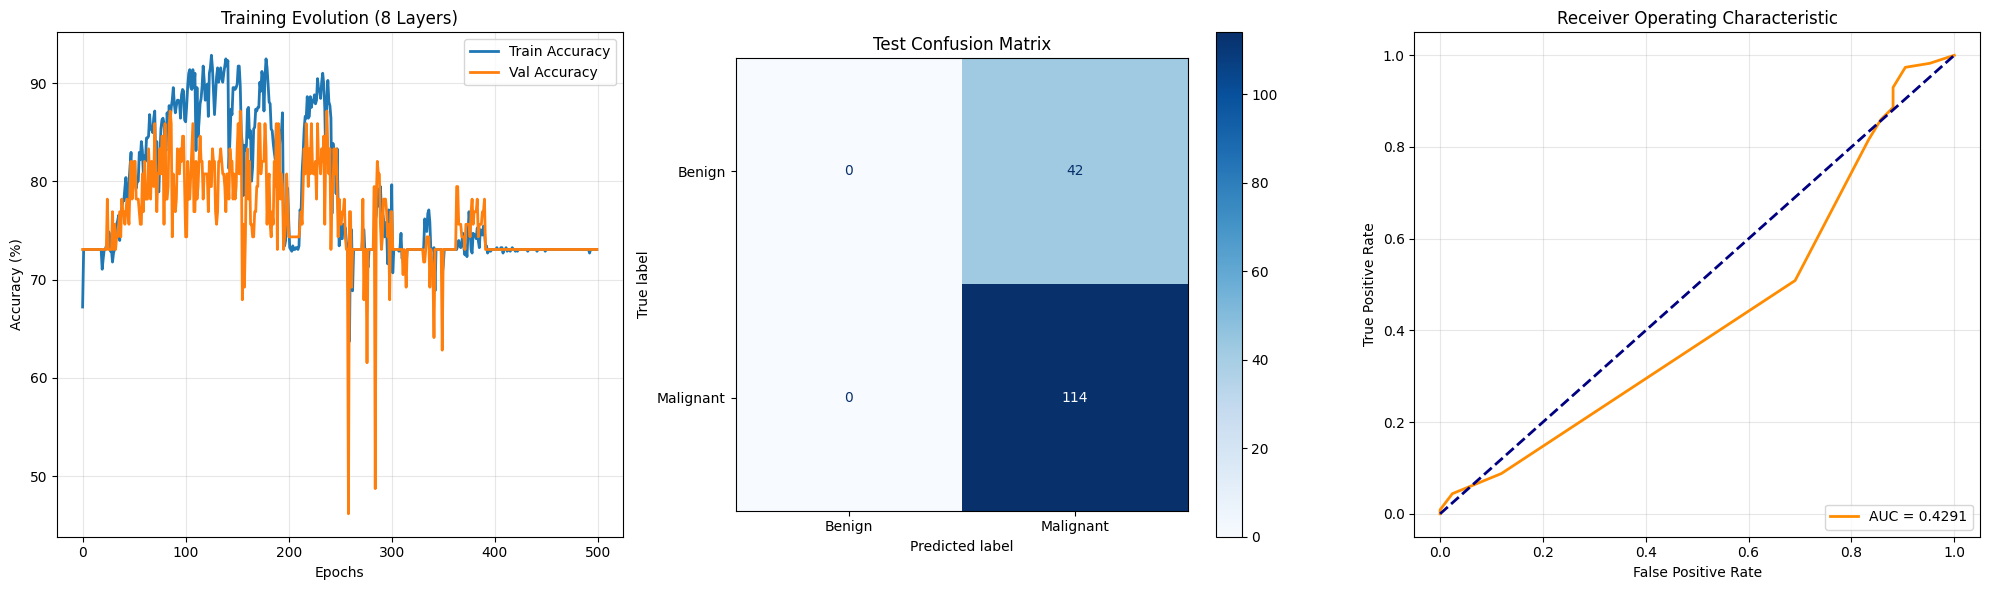

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Create a large figure for all plots
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: Training & Validation Accuracy ---
ax[0].plot(history['train_acc'], label='Train Accuracy', color='tab:blue', lw=2)
ax[0].plot(history['val_acc'], label='Val Accuracy', color='tab:orange', lw=2)
ax[0].set_title('Training Evolution (8 Layers)')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy (%)')
ax[0].legend()
ax[0].grid(alpha=0.3)

# --- Plot 2: Confusion Matrix ---
cm = confusion_matrix(y_true, y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues', ax=ax[1], values_format='d')
ax[1].set_title('Test Confusion Matrix')

# --- Plot 3: ROC Curve ---
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc_val = auc(fpr, tpr)
ax[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_val:.4f}')
ax[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[2].set_title('Receiver Operating Characteristic')
ax[2].set_xlabel('False Positive Rate')
ax[2].set_ylabel('True Positive Rate')
ax[2].legend(loc="lower right")
ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()